In [1]:
import numpy as np
import os
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
# Adjust these paths as needed
model1 = load_model("saved_model/efficientnet_b3_finetuned_v2.keras")
model2 = load_model("saved_model/mri_classifier_final.keras")  

In [5]:
TEST_DIR = "D:/college/grad project/integrated/testing"
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

In [7]:
# AUGMENTATION + ENSEMBLE PREDICTION
# -------------------------------
def augment_image(img):
    return [
        img,
        img.transpose(Image.FLIP_LEFT_RIGHT),
        img.transpose(Image.FLIP_TOP_BOTTOM),
        img.rotate(15),
        img.rotate(-15)
    ]

def predict_tta_ensemble(models, img_path):
    img = Image.open(img_path).convert("RGB")

    all_model_preds = []

    for model in models:
        input_shape = model.input_shape[1:3]
        resized_img = img.resize(input_shape)
        aug_imgs = augment_image(resized_img)
        model_preds = []

        for aug in aug_imgs:
            arr = image.img_to_array(aug) / 255.0
            arr = np.expand_dims(arr, axis=0)
            model_preds.append(model.predict(arr)[0])

        model_avg = np.mean(model_preds, axis=0)
        all_model_preds.append(model_avg)

    # Soft ensemble
    final_pred = np.mean(all_model_preds, axis=0)
    return final_pred

In [9]:
# EVALUATION
y_true = []
y_pred = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_folder = os.path.join(TEST_DIR, class_name)s
    for fname in tqdm(os.listdir(class_folder), desc=class_name):
        if fname.endswith(".jpg") or fname.endswith(".png"):
            fpath = os.path.join(class_folder, fname)
            pred = predict_tta_ensemble([model1, model2], fpath)
            y_pred.append(np.argmax(pred))
            y_true.append(class_index)

glioma_tumor:   0%|          | 0/400 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


glioma_tumor:   0%|          | 1/400 [00:07<47:41,  7.17s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


glioma_tumor:   0%|          | 2/400 [00:08<26:34,  4.01s/it]

...

pituitary_tumor:  99%|█████████▉| 372/374 [08:19<00:02,  1.18s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


pituitary_tumor: 100%|█████████▉| 373/374 [08:20<00:01,  1.17s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


pituitary_tumor: 100%|██████████| 374/374 [08:21<00:00,  1.34s/it]



Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.96      0.87      0.92       400
meningioma_tumor       0.92      0.96      0.94       421
        no_tumor       0.94      1.00      0.97       510
 pituitary_tumor       0.99      0.95      0.97       374

        accuracy                           0.95      1705
       macro avg       0.95      0.95      0.95      1705
    weighted avg       0.95      0.95      0.95      1705


Confusion Matrix:
[[349  26  24   1]
 [ 12 406   2   1]
 [  0   0 510   0]
 [  1  11   7 355]]

Per-Class Accuracy:
glioma_tumor: 87.25%
meningioma_tumor: 96.44%
no_tumor: 100.00%
pituitary_tumor: 94.92%


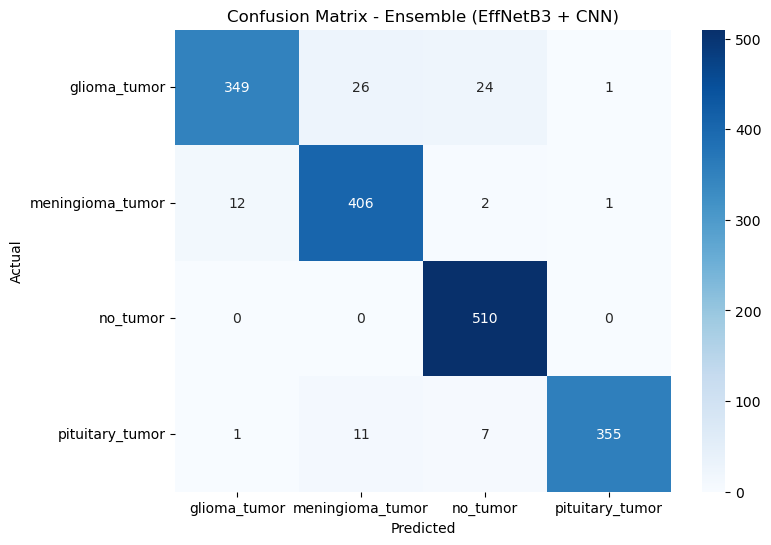

In [11]:
# METRICS
# -------------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))S

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

acc_per_class = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, label in enumerate(CLASS_NAMES):
    print(f"{label}: {acc_per_class[i]*100:.2f}%")

# Optional: Visual Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble (EffNetB3 + CNN)')
plt.show()

In [13]:
model1.save("saved_model/efficientnet_b3_finetuned_v2.keras")
model2.save("saved_model/mri_classifier_final.keras")

In [33]:
from ensemble_model import EnsembleModel
import numpy as np

CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

ensemble = EnsembleModel([
    "saved_model/efficientnet_b3_finetuned_v2.keras",
    "saved_model/mri_classifier_final.keras"
])

pred = ensemble.predict("path/to/image.jpg")
final_class = CLASS_NAMES[np.argmax(pred)]
print("Prediction:", final_class)

ImportError: cannot import name 'EnsembleModel' from 'ensemble_model' (C:\Users\DELL\project brain\ensemble_model.py)